In [1]:
# This cell can be deleted in the end.
%load_ext autoreload
%autoreload 2

import sys
sys.path.insert(1, '../')

# 07 Coupling example

In [2]:
import pyFBS

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## 3D view

In [3]:
view3D = pyFBS.view3D(show_origin = False, show_axes = False,shape =  (1,3),title = "Overview")

In [4]:
pos_xlsx = pyFBS.example_lab_testbench["meas"]["xlsx_coupling"]
view3D.plot.add_text("A structure", position='upper_left', font_size=10, color="k", font="times", name="A_structure")

view3D.plot.subplot(0,0)
view3D.plot.isometric_view()

stl_dir = pyFBS.example_lab_testbench["STL"]["A"]
view3D.add_stl(stl_dir,color = "#83afd2",name = "A");

In [5]:
df_acc_A = pd.read_excel(pos_xlsx, sheet_name='Sensors_A')
df_chn_A = pd.read_excel(pos_xlsx, sheet_name='Channels_A')
df_imp_A = pd.read_excel(pos_xlsx, sheet_name='Impacts_A')

view3D.show_acc(df_acc_A)
view3D.show_imp(df_imp_A)
view3D.show_chn(df_chn_A)

In [6]:
view3D.plot.subplot(0,1)
view3D.plot.isometric_view()
view3D.plot.add_text("B structure", position='upper_left', font_size=10, color="k", font="times", name="B_structure")

stl_dir = pyFBS.example_lab_testbench["STL"]["B"]
view3D.add_stl(stl_dir,color = "#83afd2",name = "B");

In [7]:
df_acc_B = pd.read_excel(pos_xlsx, sheet_name='Sensors_B')
df_chn_B = pd.read_excel(pos_xlsx, sheet_name='Channels_B')
df_imp_B = pd.read_excel(pos_xlsx, sheet_name='Impacts_B')

view3D.show_acc(df_acc_B,overwrite = False)
view3D.show_imp(df_imp_B,overwrite = False)
view3D.show_chn(df_chn_B,overwrite = False)

In [8]:
view3D.plot.subplot(0,2)
view3D.plot.isometric_view()
view3D.plot.add_text("AB structure", position='upper_left', font_size=10, color="k", font="times", name="AB_structure");

stl_dir = pyFBS.example_lab_testbench["STL"]["AB"]
view3D.add_stl(stl_dir,color = "#83afd2",name = "AB");

In [9]:
df_acc_AB = pd.read_excel(pos_xlsx, sheet_name='Sensors_AB')
df_chn_AB = pd.read_excel(pos_xlsx, sheet_name='Channels_AB')
df_imp_AB = pd.read_excel(pos_xlsx, sheet_name='Impacts_AB')

view3D.show_acc(df_acc_AB,overwrite = False)
view3D.show_imp(df_imp_AB,overwrite = False)
view3D.show_chn(df_chn_AB,overwrite = False)

Views can be linked rather simply.

In [10]:
view3D.plot.link_views()
#view3D.plot.unlink_views()

## FEM model

In [11]:
full_file_AB = pyFBS.example_lab_testbench["FEM"]["AB_full"]
ress_file_AB = pyFBS.example_lab_testbench["FEM"]["AB_rst"]

full_file_B = pyFBS.example_lab_testbench["FEM"]["B_full"]
ress_file_B = pyFBS.example_lab_testbench["FEM"]["B_rst"]

full_file_A = pyFBS.example_lab_testbench["FEM"]["A_full"]
ress_file_A = pyFBS.example_lab_testbench["FEM"]["A_rst"]

In [12]:
MK_A = pyFBS.MK_model(ress_file_A,full_file_A,no_modes = 100,allow_pickle= False,recalculate = False)
MK_B = pyFBS.MK_model(ress_file_B,full_file_B,no_modes = 100,allow_pickle= False,recalculate = False)
MK_AB = pyFBS.MK_model(ress_file_AB,full_file_AB,no_modes = 100,allow_pickle= False,recalculate = False)

In [13]:
df_chn_A_up = MK_A.update_locations_df(df_chn_A)
df_imp_A_up = MK_A.update_locations_df(df_imp_A)

In [14]:
df_chn_B_up = MK_B.update_locations_df(df_chn_B)
df_imp_B_up = MK_B.update_locations_df(df_imp_B)

In [15]:
df_chn_AB_up = MK_AB.update_locations_df(df_chn_AB)
df_imp_AB_up = MK_AB.update_locations_df(df_imp_AB)

In [16]:
MK_A.FRF_synth(df_chn_A_up,df_imp_A_up,f_start = 0,modal_damping = 0.003)
MK_B.FRF_synth(df_chn_B_up,df_imp_B_up,f_start = 0,modal_damping = 0.003)
MK_AB.FRF_synth(df_chn_AB_up,df_imp_AB_up,f_start = 0,modal_damping = 0.003)

## VPT 

In [17]:
df_vp = pd.read_excel(pos_xlsx, sheet_name='VP_Channels')
df_vpref = pd.read_excel(pos_xlsx, sheet_name='VP_RefChannels')

vpt_A = pyFBS.VPT(df_chn_A_up,df_imp_A_up,df_vp,df_vpref)
vpt_B = pyFBS.VPT(df_chn_B_up,df_imp_B_up,df_vp,df_vpref)

In [18]:
vpt_A.apply_VPT(MK_A.freq,MK_A.FRF)
vpt_B.apply_VPT(MK_B.freq,MK_B.FRF)

#vpt.consistency([1],[1])

Text(0, 0.5, 'Output DoFs')

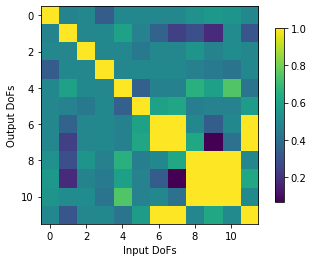

In [19]:
coh_crit = pyFBS.utility.coh_on_FRF(vpt_A.vptData)

plt.imshow(coh_crit)
plt.colorbar(shrink = 0.8)


plt.xlabel("Input DoFs")
plt.ylabel("Output DoFs")

Text(0, 0.5, 'Output DoFs')

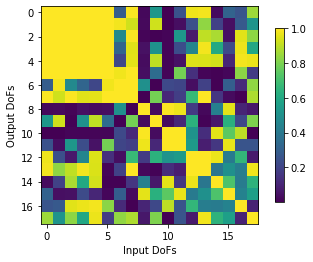

In [20]:
coh_crit = pyFBS.utility.coh_on_FRF(vpt_B.vptData)

plt.imshow(coh_crit)
plt.colorbar(shrink = 0.8)

plt.xlabel("Input DoFs")
plt.ylabel("Output DoFs")

In [21]:
freq = MK_A.freq
Y_A = vpt_A.vptData
Y_B = vpt_B.vptData

display(Y_A.shape,Y_B.shape)

(2000, 12, 12)

(2000, 18, 18)

## Coupling

In [22]:
from numpy.linalg import svd
from tqdm import tqdm

In [23]:
Y_AnB = np.zeros((2000,12+18,12+18),dtype = complex)

Y_AnB[:,0:12,0:12] = Y_A
Y_AnB[:,12:,12:] =   Y_B

k = 6


Bu = np.zeros((k,12+18))
Bu[:k,6:6+k] = 1*np.eye(k)
Bu[:k,12:12+k] = -1*np.eye(k)

Bf = np.zeros((k,12+18))
Bf[:k,6:6+k] = 1*np.eye(k)
Bf[:k,12:12+k] = -1*np.eye(k)

#plt.figure()
#plt.imshow(Bu)
#plt.figure()
#plt.imshow(Bf)


Y_ABn = np.zeros_like(Y_AnB,dtype = complex)

Y_int = Bu@Y_AnB@Bf.T
Y_ABn =Y_AnB - Y_AnB@Bf.T@np.linalg.pinv(Y_int)@Bu@Y_AnB

In [24]:
arr_coup = [0,1,2,3,4,5,18,19,20,21,22,23,24,25,26,27,28,29]
Y_AB_coupled = Y_ABn[:,arr_coup,:][:,:,arr_coup]
Y_AB_ref = MK_AB.FRF

,Name,Description,Type,Quantity,Unit,Component,NodeNumber,Grouping,Position_1,Position_2,Position_3,Direction_1,Direction_2,Direction_3,Notes
0,S1 X,AM_AB_final,Translation,Acceleration,m/s^2,AM_AB_final,1,100,-0.07554,0.14157,0.017,0.705057,0.70915,0,NaN


,Name,Description,NodeNumber,Grouping,Quantity,Unit,Position_1,Position_2,Position_3,Direction_1,Direction_2,Direction_3
6,H28,AM_AB_final,16,10,Force,N,0.112653,0.258984,-0.0105,-0.087156,0.996195,0.0


(0, 2000)

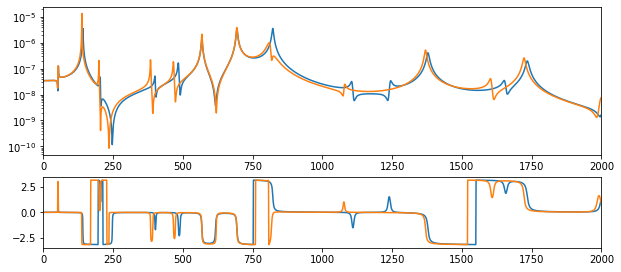

In [25]:
s1 = 0
s2 = 6

display(df_chn_AB_up.loc[[s1]])
display(df_imp_AB_up.loc[[s2]])

plt.figure(figsize = (10,6))
plt.subplot(211)
plt.semilogy(freq,np.abs(Y_AB_ref[:,s1,s2]))
plt.semilogy(freq,np.abs(Y_AB_coupled[:,s1,s2]))

plt.xlim(0,2000)

plt.subplot(413)
plt.plot(freq,np.angle(Y_AB_ref[:,s1,s2]))
plt.plot(freq,np.angle(Y_AB_coupled[:,s1,s2]))


plt.xlim(0,2000)



## ODS animation

In [26]:
view3D_an = pyFBS.view3D(show_origin = False, show_axes = False,title = "Animation")

In [27]:
stl_dir = pyFBS.example_lab_testbench["STL"]["AB"]
view3D_an.add_stl(stl_dir,color = "#83afd2",name = "AB");

In [28]:
view3D_an.show_acc(df_acc_AB,overwrite = False)
view3D_an.show_imp(df_imp_AB_up,overwrite = False)
view3D_an.show_chn(df_chn_AB_up,overwrite = False)

view3D_an.label_acc(df_acc_AB,name = "acc_AB")
view3D_an.label_chn(df_chn_AB_up,name = "chn_AB")
view3D_an.label_imp(df_imp_AB_up,name = "imp_AB")

(0, 2000)

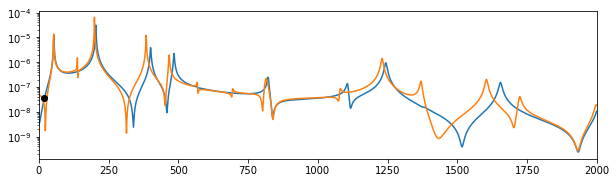

In [29]:
freq_sel = 20
s1 = 15
select_in = 6

plt.figure(figsize = (10,6))
plt.subplot(211)

plt.semilogy(freq,np.abs(Y_AB_ref[:,s1,select_in]))
plt.semilogy(freq,np.abs(Y_AB_coupled[:,s1,select_in]))

plt.semilogy(freq[freq_sel],np.abs(Y_AB_ref[freq_sel,s1,select_in]),'o',color = "k")

plt.xlim(0,2000)

## Coupled

In [32]:
ann = pyFBS.orient_in_global(Y_AB_coupled[freq_sel,:,select_in],df_chn_AB_up,df_acc_AB)

mode_dict = pyFBS.dict_animation(ann,"object",object_list = view3D_an.global_acc,r_scale=30)
mode_dict["freq"] = freq[freq_sel]
view3D_an.add_objects_animation(mode_dict,run_animation = True,add_note= True)

## Reference

In [31]:
ann = pyFBS.orient_in_global(Y_AB_ref[freq_sel,:,select_in],df_chn_AB_up,df_acc_AB)

mode_dict = pyFBS.dict_animation(ann,"object",object_list = view3D_an.global_acc,r_scale=30)
mode_dict["freq"] = freq[freq_sel]
view3D_an.add_objects_animation(mode_dict,run_animation = True,add_note= True)